<a href="https://colab.research.google.com/github/nguoitinhmuadong-1/Project2/blob/main/Adora.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 23.4 MB/s eta 0:00:00


In [2]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 66.0 MB/s eta 0:00:00


In [3]:
!pip install streamlit geopy

In [4]:
!pip install streamlit geopy requests

In [5]:
!pip install streamlit-folium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.5/530.5 kB 14.0 MB/s eta 0:00:00


In [6]:
import numpy as np
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ===== 1. ĐỌC DATA =====
df = pd.read_excel("/content/bandau_khongphuong.xlsx")

# ===== 2. CLEAN DATA =====
# Đổi Có/Không → 1/0 (nếu còn)
mapping = {"Có": 1, "Không": 0}
for col in df.columns:
    df[col] = df[col].replace(mapping)


# Xoá dòng thiếu
df = df.dropna()

# ===== 3. ÉP KIỂU SỐ =====
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna()

# ===== 4. CHỌN FEATURE =====
X = df[["distance", "area", "tien_nghi", "gio_giac", "so_nguoi", "tien_ich"]]
y = df["price"]
# ===== 5. TRAIN =====
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

# ===== 6. ĐÁNH GIÁ =====
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)


rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

# ===== 7. LƯU MODEL =====
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

print("✅ Train xong và đã lưu model!")




MAE: 1136422.81638522
RMSE: 1404757.657767041
R2: 0.15888322021433743
✅ Train xong và đã lưu model!


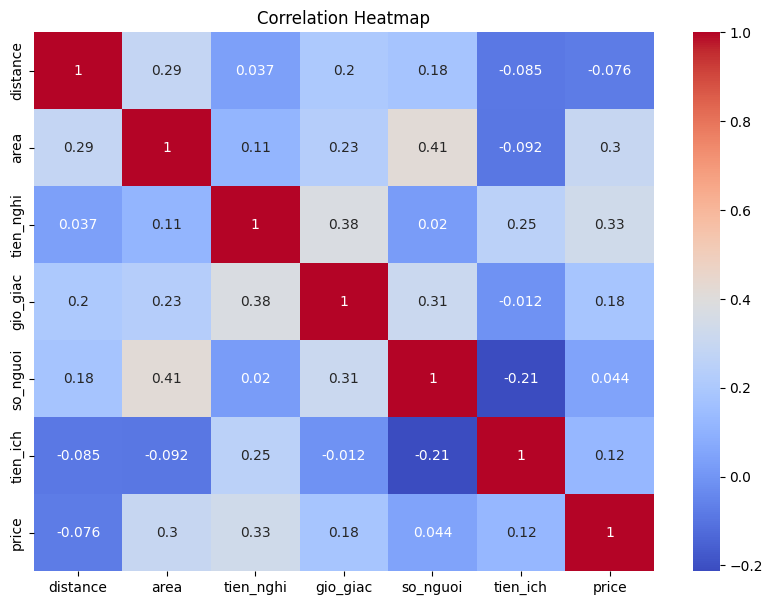

In [7]:
#Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

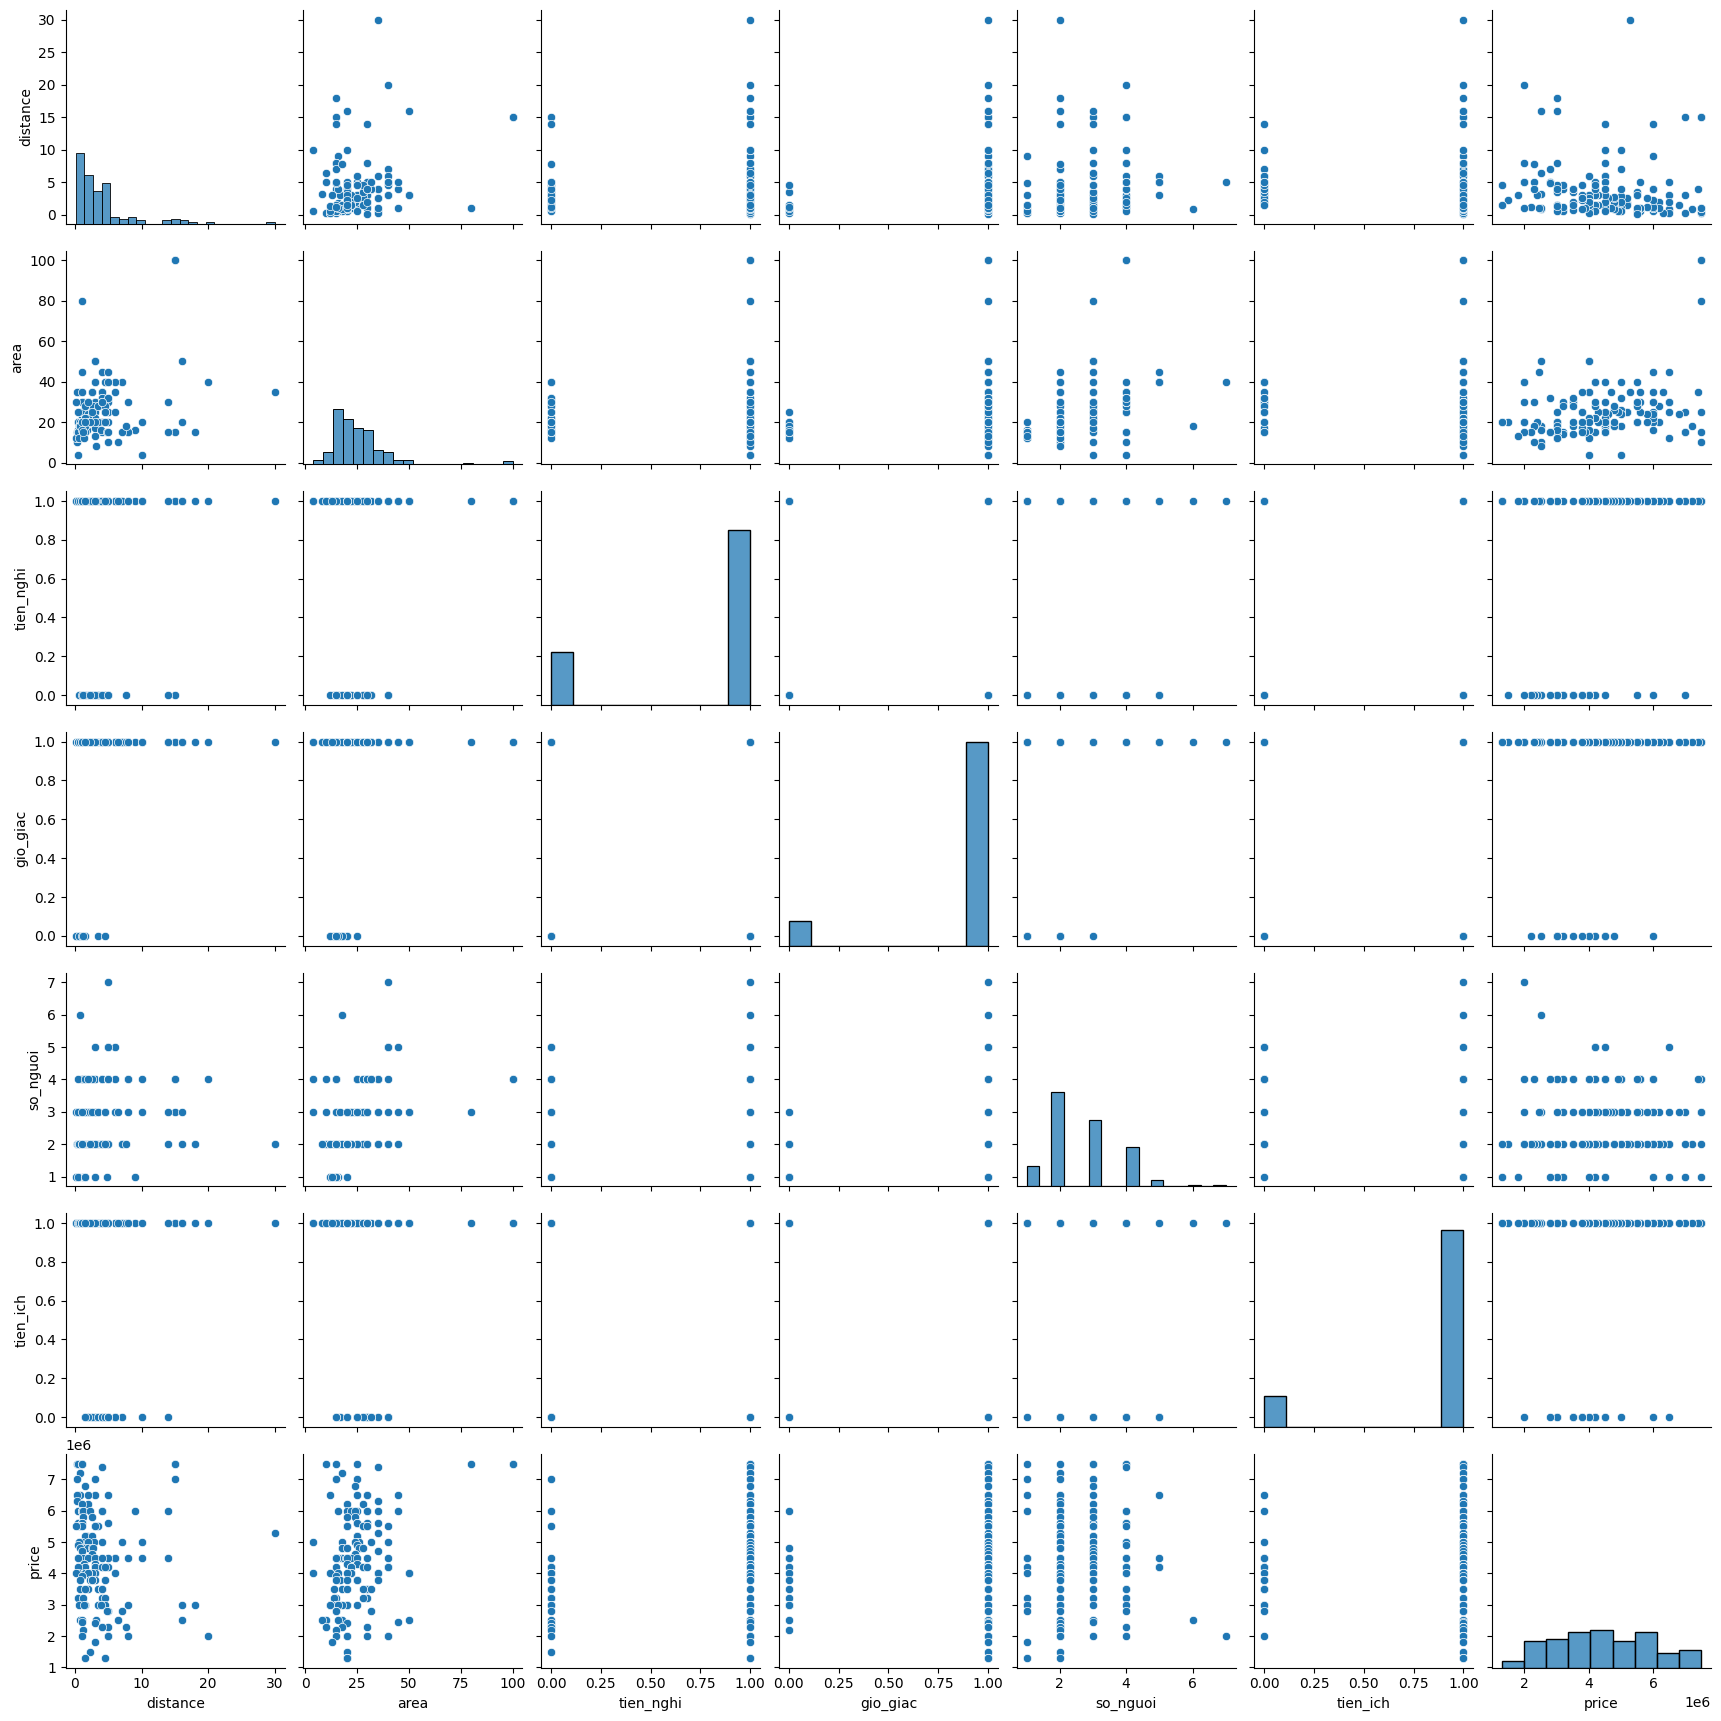

In [8]:
sns.pairplot(df)

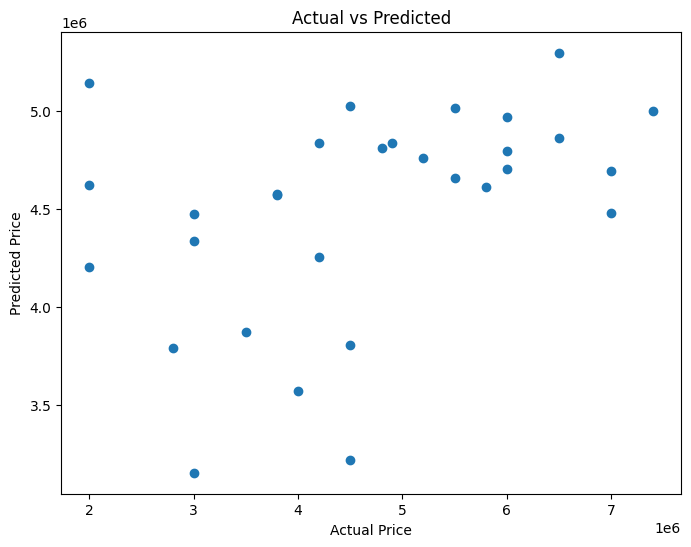

In [9]:
#bieudoactualvspredict
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

plt.show()

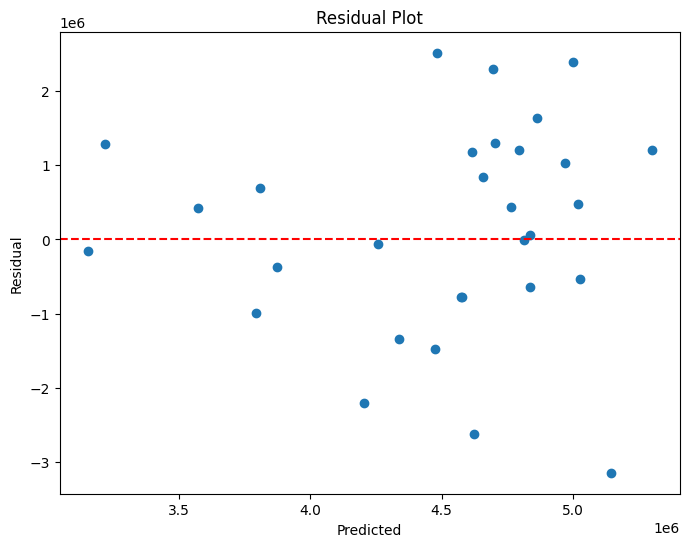

In [10]:
#Bieudosaiso
residual = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residual)

plt.axhline(y=0, color='r', linestyle='--')

plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

In [11]:
import streamlit as st
import pickle
import numpy as np
import requests
import folium
from folium.plugins import HeatMap, MiniMap
from streamlit_folium import st_folium
import pandas as pd
import time
from geopy.geocoders import Nominatim

# ===== CONFIG =====
st.set_page_config(page_title="ADORA", layout="centered")

# ===== SESSION =====
if "show_result" not in st.session_state:
    st.session_state.show_result = False

if "geo" not in st.session_state:
    st.session_state.geo = None

# ===== STYLE =====
st.markdown("""
<style>

/* Nền toàn app */
.stApp {
    background: linear-gradient(135deg, #ff9a9e, #fecfef);
}

/* Xoá nền trắng mặc định */
.block-container {
    background: transparent !important;
}

/* Input sáng nhẹ */
.stTextInput, .stNumberInput, .stSelectbox {
    background-color: rgba(255,255,255,0.25);
    border-radius: 12px;
    padding: 10px;
}

/* Label */
label {
    color: #333 !important;
    font-weight: 600;
}

/* Nút nổi */
.stButton button {
    background: linear-gradient(90deg, #ff4b2b, #ff416c);
    color: white;
    border-radius: 12px;
    height: 50px;
    font-size: 18px;
    width: 100%;
    border: none;
    box-shadow: 0 4px 15px rgba(0,0,0,0.2);
}

/* Card kết quả trắng */
.result-box {
    background: white;
    padding: 25px;
    border-radius: 16px;
    text-align: center;
    box-shadow: 0 6px 20px rgba(0,0,0,0.2);
}

</style>
""", unsafe_allow_html=True)
# ===== HEADER =====
st.markdown("""
<h1 style='text-align: center;'>🏠 ADORA</h1>
<p style='text-align: center; color: gray;'>Smart rent. Better choice.</p>
""", unsafe_allow_html=True)

# ===== LOAD MODEL =====
model = pickle.load(open("model.pkl", "rb"))

# ===== API KEY =====
API_KEY = "eyJvcmciOiI1YjNjZTM1OTc4NTExMTAwMDFjZjYyNDgiLCJpZCI6IjMzNDdmOTk2ZDI4NjQ3NzQ4ZjQ1YjYwNGZjYjBiY2Y3IiwiaCI6Im11cm11cjY0In0="

# ===== CAMPUS (lat, lon) =====
campuses = {
    "UEH - Cơ sở A": (10.78316375006458, 106.6946721972536),
    "UEH - Cơ sở B": (10.761242919118299, 106.6687259453133),
    "UEH - Cơ sở N": (10.706330027897318, 106.64029545754002)
}

# ===== INPUT =====
col1, col2 = st.columns(2)

with col1:
    address = st.text_input("📍 Địa chỉ")
    area = st.number_input("📐 Diện tích (m²)", min_value=0.0)

with col2:
    so_nguoi = st.number_input("👥 Số người", min_value=1)
    campus_name = st.selectbox("🏫 Cơ sở", list(campuses.keys()))

tien_nghi = st.selectbox("❄️ Tiện nghi", ["Có", "Không"])
gio_giac = st.selectbox("⏰ Giờ giấc tự do", ["Có", "Không"])
tien_ich = st.selectbox("🏪 Tiện ích xung quanh", ["Có", "Không"])

tien_nghi = 1 if tien_nghi == "Có" else 0
gio_giac = 1 if gio_giac == "Có" else 0
tien_ich = 1 if tien_ich == "Có" else 0

# ===== GEO (CACHE) -> (lat, lon) =====
@st.cache_data(show_spinner=False)
def geocode_cached(address):
    geolocator = Nominatim(user_agent="adora_app")
    for _ in range(3):
        try:
            loc = geolocator.geocode(address, timeout=10)
            if loc:
                return loc.latitude, loc.longitude  # (lat, lon)
        except:
            time.sleep(1)
    return 10.7769, 106.7009  # fallback HCM

# ===== DISTANCE (km) =====
def get_distance(coord1, coord2):
    # coord = (lat, lon)
    try:
        url = "https://api.openrouteservice.org/v2/directions/driving-car"
        headers = {
            "Authorization": API_KEY,
            "Content-Type": "application/json"
        }
        body = {
            "coordinates": [
                [coord1[1], coord1[0]],  # ORS cần (lon, lat)
                [coord2[1], coord2[0]]
            ]
        }
        res = requests.post(url, json=body, headers=headers)
        data = res.json()
        return data["routes"][0]["summary"]["distance"] / 1000
    except:
        # fallback haversine đơn giản
        return np.sqrt(
            (coord1[0] - coord2[0])**2 +
            (coord1[1] - coord2[1])**2
        ) * 111

# ===== LOAD DATA REAL + FIX =====
@st.cache_data
def load_real_data():
    df = pd.read_excel("bandau_full.xlsx")

    # chuẩn hoá tên cột
    df = df.rename(columns={
        "latitude": "lat",
        "longitude": "lon",
        "Lat": "lat",
        "Lng": "lon"
    })

    df = df.dropna(subset=["lat", "lon"])

    fixed = []

    for _, r in df.iterrows():
        lat = r["lat"]
        lon = r["lon"]

        # auto-fix đảo nếu bị swap
        if lat > 50:  # VN lat ~10-11
            lat, lon = lon, lat

        # auto-fix scale (vd 106700)
        if lat > 1000:
            lat /= 10000
            lon /= 10000

        fixed.append((lat, lon))

    return fixed

# ===== BUTTON =====
if st.button("🔮 Dự đoán ngay"):
    st.session_state.show_result = True
    st.session_state.geo = None

# ===== RESULT =====
if st.session_state.show_result:

    if not address:
        st.warning("⚠️ Vui lòng nhập địa chỉ")
        st.stop()

    if st.session_state.geo is None:
        st.session_state.geo = geocode_cached(address.strip())

    geo = st.session_state.geo          # (lat, lon)
    campus_coord = campuses[campus_name]# (lat, lon)

    distance = get_distance(geo, campus_coord)

    features = np.array([[distance, area, tien_nghi, gio_giac, so_nguoi, tien_ich]])
    price = model.predict(features)[0]

    # ===== RESULT CARD =====
    st.markdown(f"""
    <div style='background-color:#1e1e2f;padding:20px;border-radius:15px;text-align:center;'>
        <h3 style='color:#00ffcc;'>📏 {distance:.2f} km</h3>
        <h2 style='color:#ff4b4b;'>💰 {int(price):,} VND</h2>
        <p style='color:gray;'>Giá dự đoán</p>
    </div>
    """, unsafe_allow_html=True)

    # ===== HEATMAP =====
    st.markdown("### 🔥 Bản đồ HeatMap giá trọ")

    points = load_real_data()
    if len(points) > 1000:
        points = points[:800]

    heat_data = []

    for lat, lon in points:
        d = np.sqrt(
            (lat - campus_coord[0])**2 +
            (lon - campus_coord[1])**2
        ) * 111

        features = np.array([[d, area, tien_nghi, gio_giac, so_nguoi, tien_ich]])
        price = model.predict(features)[0]

        heat_data.append([lat, lon, price])

    # ===== MAP =====
    m = folium.Map(
        location=[geo[0], geo[1]],  # lat, lon
        zoom_start=14,
        tiles="CartoDB positron"
    )

    HeatMap(
        heat_data,
        radius=20,
        blur=18,
        max_zoom=15,
        gradient={
            0.2: 'purple',
            0.4: 'blue',
            0.6: 'cyan',
            0.8: 'orange',
            1.0: 'red'
        }
    ).add_to(m)

    # user
    folium.Marker(
        [geo[0], geo[1]],
        popup="📍 Bạn ở đây",
        icon=folium.Icon(color="red",icon='user')
    ).add_to(m)

    # campus
    folium.Marker(
        [campus_coord[0], campus_coord[1]],
        popup="🏫 Trường",
        icon=folium.Icon(color="blue",icon='home')
    ).add_to(m)

    folium.Circle(
        location=[geo[0], geo[1]],
        radius=500,
        color='red',
        fill=True,
        fill_opacity=0.1
    ).add_to(m)

    MiniMap().add_to(m)

    st_folium(m, width=750, height=550)


2026-05-07 16:07:50.572 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-07 16:07:51.854 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-07 16:07:51.858 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-07 16:07:51.860 Session state does not function when running a script without `streamlit run`
2026-05-07 16:07:51.862 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-07 16:07:51.868 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-07 16:07:51.873 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-07 16:07:51.877 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-07 16:07